#### Libraries

In [1]:
from numpy import *
from matplotlib.pyplot import *
import pandas as pd

# First direction
There are 2 micrometers. This is using the horizonatal one.

### Taking Data

In [2]:
LC = 0.01

In [3]:
X = [
#MSR,CSR
[5,4],#2
[4.5,42],#3
[4.5,26],#4
[4.5,18],#5
[4.5,6],#6
[4,48],#7
[4,40],#8
[4,30],#9
[4,22],#10
[4,14],#11
[4,6],#12
[4,0],#13
[3.5,44],#14
[3.5,37],#15
[3.5,29],#16
[3.5,23],#17
[3.5,17],#18
[3.5,8],#19
[3.5,4],#20
[3.5,0],#21
]
X = array(X)
X = X[:,0] + X[:,1] * LC

In [4]:
Xd = [
#MSR,CSR
[6.5,28],#2
[6.5,45],#3
[7,6],#4
[7,16],#5
[7,26],#6
[7,30],#7
[7,37],#8
[7,45],#9
[7.5,3],#10
[7.5,9],#11
[7.5,15],#12
[7.5,22],#13
[7.5,30],#14
[7.5,36],#15
[7.5,42],#16
[7.5,46],#17
[8,1],#18
[8,4],#19
[8,7],#20
[8,9],#21
]
Xd = array(Xd)
Xd = Xd[:,0] + Xd[:,1] * LC

In [5]:
X0 = 5.89

Text(0, 0.5, '$X_m \\text{ (mm)}$')

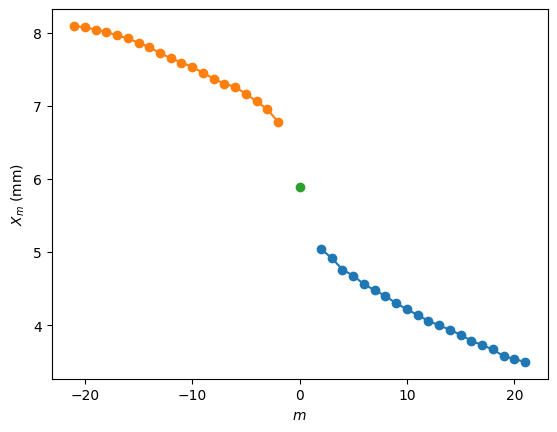

In [6]:
plot(range(2,len(X)+2),X,'-o')
plot(range(-2,-len(X)-2,-1),Xd,'-o')
plot(0,X0,'o')
xlabel("$m$")
ylabel(r"$X_m \text{ (mm)}$")

### Diameter

In [7]:
n = len(X)
D = [X[i] - Xd[i] for i in range(n)]
D2 = [x**2 for x in D]

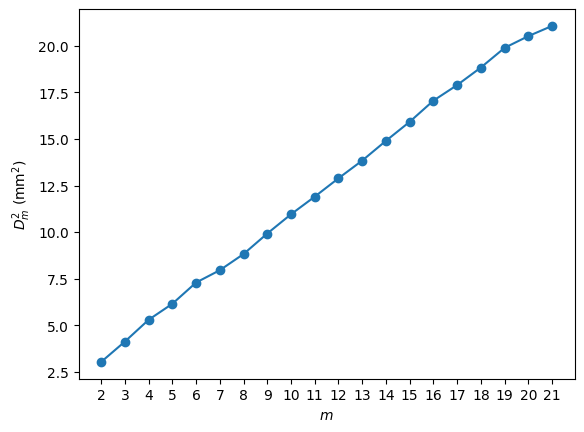

In [8]:
plot(range(2,n+2),D2,"-o")
xlabel("$ m $")
ylabel(r"$ D_m^2 \ (\text{mm}^2)$")
xticks(range(2,n+2))
show()

### Error in radius and slope

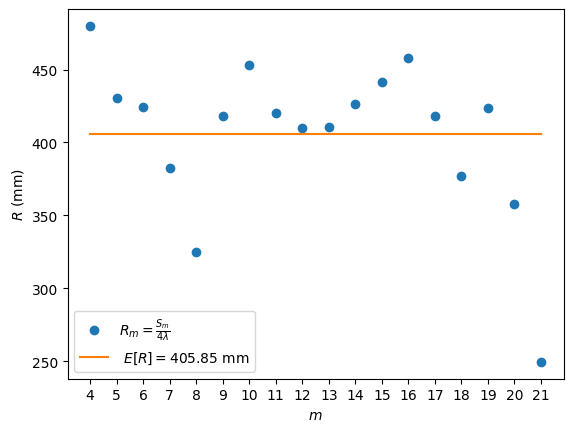

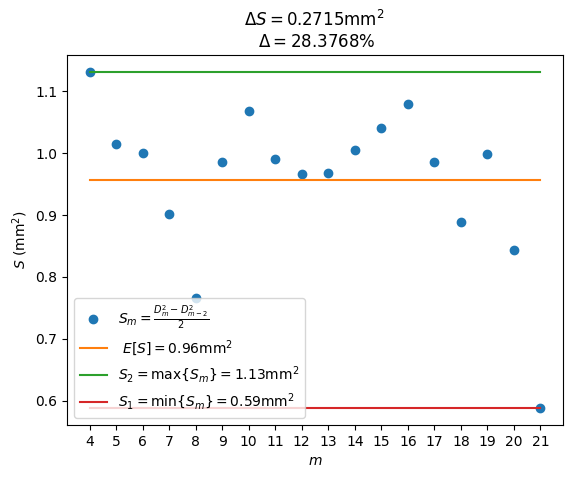

In [9]:
S = [(D2[m] - D2[m-2])/2 for m in range(2,n)]
# S = 4 lambda R
lamb = 5893e-7 # mm
R = [S[m]/(4*lamb) for m in range(n-2)] # mm
plot(range(4,n+2),R,'o')
Rexp = sum(R)/len(R)
plot(range(4,n+2),[Rexp]*(n-2))
legend([r"$ R_m = \frac{S_m}{4 \lambda}$",f" $ E[R] = {round(Rexp,2)}$ mm"])
xticks(range(4,n+2))
xlabel("$m$")
ylabel(r"$R \ (\text{mm})$")
figure()
plot(range(4,n+2),S,'o')
plot(range(4,n+2),[mean(S)]*(n-2))
plot(range(4,n+2),[max(S)]*(n-2))
plot(range(4,n+2),[min(S)]*(n-2))
legend([r"$ S_m = \frac{D_m^2 - D_{m-2}^2}{2}$",f" $ E[S] = {round(mean(S),2)}"+r" \text{mm}^2 $ ",
        r"$ S_2 = \max\{S_m\} = " + f"{round(max(S),2)}" + r"\text{mm}^2 $",
        r"$ S_1 = \min\{ S_m\} = " + f"{round(min(S),2)}" + r"\text{mm}^2 $"
        ],loc="lower left")
title(
        r"$\Delta S = " + str(round((max(S) - min(S))/2,4)) + r"\text{mm}^2" + " $ \n" + 
    r" $ \Delta = " + str(round(100*((max(S) - min(S))*len(S))/(2*sum(S)),4)) + "\% $ ")
xticks(range(4,n+2))
xlabel("$ m $")
ylabel(r"$S \ (\text{mm}^2)$")
show()

### Regression

Expected : 
$$
D_m^2 = 4m\lambda R
$$
where $ m $ is number of ring (bright or dark, doesn't matter)

Odd $ m $ is bright and even is dark.

More practical :
$$
D_m^2 = 4m\lambda R + C
$$

(0.0, 23.17491)

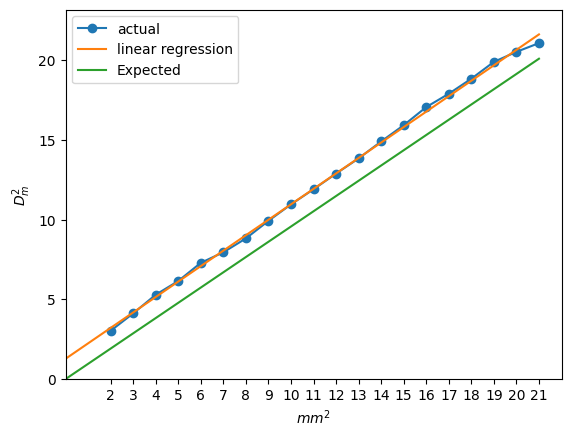

In [10]:
Y = array(D2)
X = array([[4*m*lamb,1] for m in range(2,n+2)])
pseudo_inv = linalg.inv(X.T @ X) @ X.T
theta = dot(pseudo_inv,Y)
R,C = theta
plot(range(2,n+2),Y,'-o')
plot([0,n+1],[4*m*lamb*R + C for m in [0,n+1]])
#Rexp = mean([D2[m-2]/(2*m) for m in range(2,n+2)])
plot(range(n+2),[4*m*lamb*Rexp for m in range(n+2)])
legend(["actual","linear regression","Expected"])
xlim(0,n+2)
xticks(range(2,n+2))
xlabel("$ mm^2 $")
ylabel("$ D^2_m $")
ylim(0,1.1 *max(D2))

### For last question

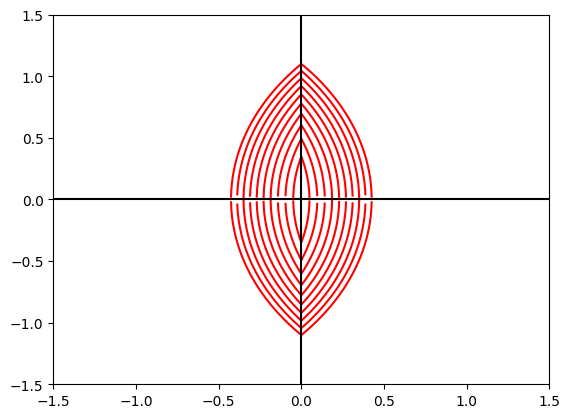

In [11]:
k = 5*lamb
x = linspace(-3,3,10000)
for p in range(10,0,-1):
    y = (R*(p*lamb/2 - 2*k*abs(x)) - x**2)
    xp = x[where(y>=0)]
    y = y[where(y>=0)]
    y = y ** 0.5
    plot(xp,y,'r')
    plot(xp,-y,'r')
xlim(-1.5,1.5)
ylim(-1.5,1.5)
plot([-1.5,1.5],[0,0],'black')
plot([0,0],[-1.5,1.5],'black')


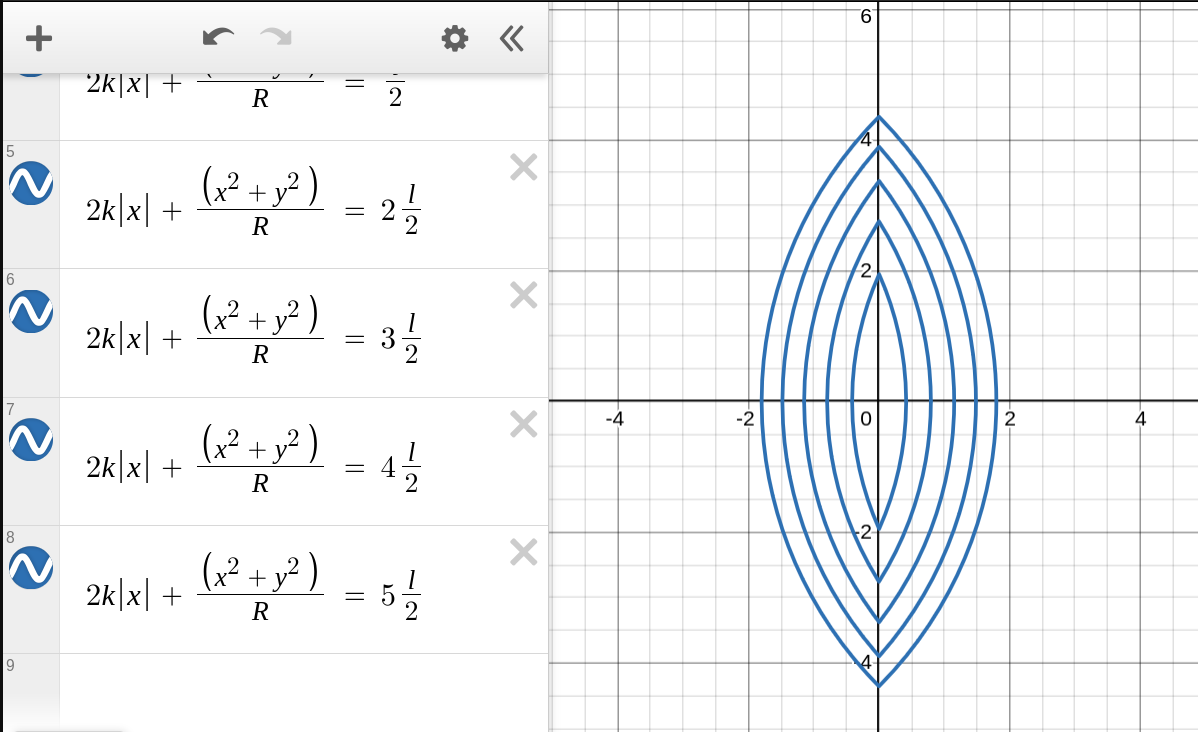

# Other direction
(using the other micrometer)

(20,) (20,) (20,)


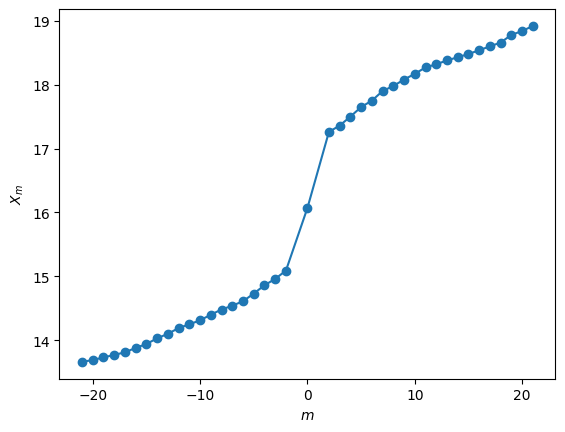

In [12]:
import pandas as pd
df = pd.read_csv("ReadingsY.csv",index_col=0)
df["X"] = dot(df.values,[1,0.01])
Xd = df.values[:20][::-1][:,2]
X = df.values[21:][:,2]
X0 = df.values[20][2]
print(X.shape,Xd.shape,df.index.values[21:].shape)
DF = pd.DataFrame({"X":X,"X'":Xd,"D":absolute(X-Xd),"D^2":(X-Xd)**2},index=df.index.values[21:])
plot(df.index,df['X'],'-o')
xlabel("$ m $")
ylabel("$ X_m $")
DF["D^2"] = around(DF["D^2"].values,4)
DF["D"] = around(DF["D"].values,4)
DF.to_csv("Data.csv")

### Diameter

In [13]:
n = len(X)
D = [X[i] - Xd[i] for i in range(n)]
D2 = [x**2 for x in D]

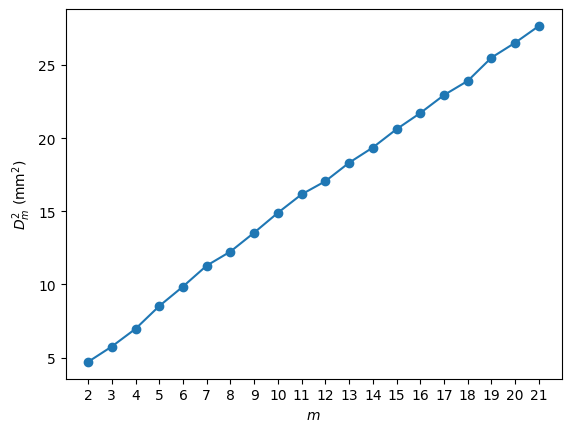

In [14]:
plot(range(2,n+2),D2,"-o")
xlabel("$ m $")
ylabel(r"$ D_m^2 \ (\text{mm}^2)$")
xticks(range(2,n+2))
show()

### Error in radius and slope

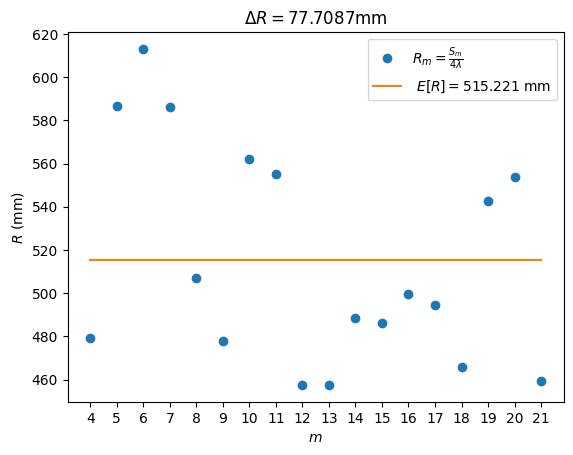

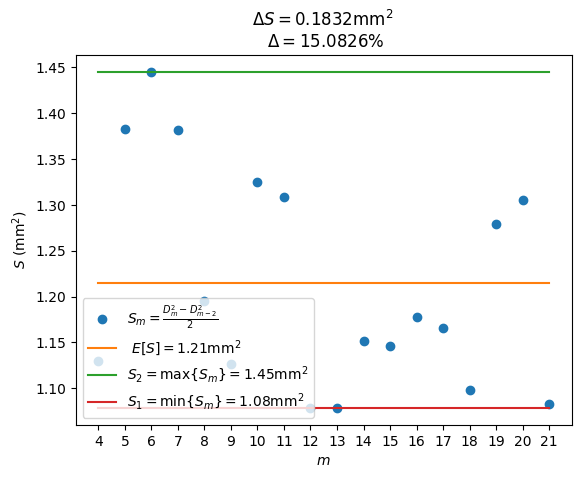

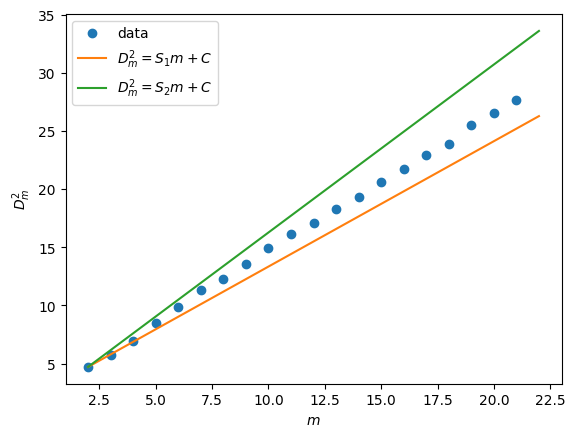

In [15]:
S = [(D2[m] - D2[m-2])/2 for m in range(2,n)]
# S = 4 lambda R
lamb = 5893e-7 # mm
R = [S[m]/(4*lamb) for m in range(n-2)] # mm
plot(range(4,n+2),R,'o')
Rexp = mean(R)
plot(range(4,n+2),[Rexp]*(n-2))
legend([r"$ R_m = \frac{S_m}{4 \lambda}$",f" $ E[R] = {round(Rexp,3)}$ mm"])
xticks(range(4,n+2))
xlabel("$m$")
ylabel(r"$R \ (\text{mm})$")
title(r"$\Delta R = " + str(round((max(R)-min(R))/2,4)) + r"\text{mm} $")
figure()
plot(range(4,n+2),S,'o')
plot(range(4,n+2),[mean(S)]*(n-2))
plot(range(4,n+2),[max(S)]*(n-2))
plot(range(4,n+2),[min(S)]*(n-2))
legend([r"$ S_m = \frac{D_m^2 - D_{m-2}^2}{2}$",f" $ E[S] = {round(mean(S),2)}"+r" \text{mm}^2 $ ",
        r"$ S_2 = \max\{S_m\} = " + f"{round(max(S),2)}" + r"\text{mm}^2 $",
        r"$ S_1 = \min\{ S_m\} = " + f"{round(min(S),2)}" + r"\text{mm}^2 $"
        ],loc="lower left")
title(
        r"$\Delta S = " + str(round((max(S) - min(S))/2,4)) + r"\text{mm}^2" + " $ \n" + 
    r" $ \Delta = " + str(round(100*((max(S) - min(S))*len(S))/(2*sum(S)),4)) + "\% $ ")
xticks(range(4,n+2))
xlabel("$ m $")
ylabel(r"$S \ (\text{mm}^2)$")
figure()
plot(range(2,22),D2,'o')
t = linspace(2,22,1000)
plot(t,D2[0] + min(S)*(t-2))
plot(t,D2[0] + max(S)*(t-2))
xlabel("$m$")
ylabel("$D_m^2$")
legend(["data","$ D_m^2 = S_1 m + C$","$ D_m^2 = S_2 m + C$"])
show()

### Regression

Expected : 
$$
D_m^2 = 4m\lambda R
$$
where $ m $ is number of ring (bright or dark, doesn't matter)

Odd $ m $ is bright and even is dark.

More practical :
$$
D_m^2 = 4m\lambda R + C
$$

(0.0, 30.434360000000023)

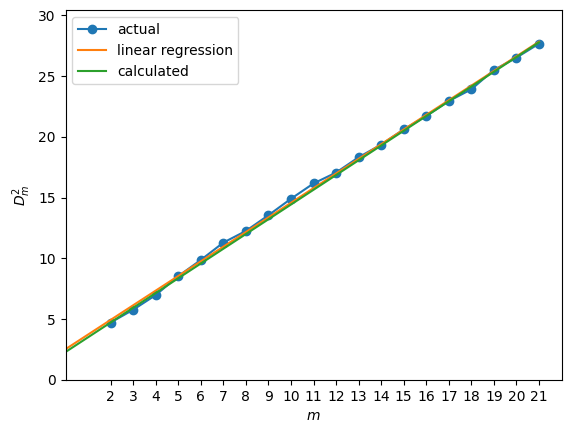

In [16]:
Y = array(D2)
X = array([[4*m*lamb,1] for m in range(2,n+2)])
pseudo_inv = linalg.inv(X.T @ X) @ X.T
theta = dot(pseudo_inv,Y)
R,C = theta
plot(range(2,n+2),Y,'-o')
plot([0,n+1],[4*m*lamb*R + C for m in [0,n+1]])
#Rexp = mean([D2[m-2]/(2*m) for m in range(2,n+2)])
plot(range(n+2),[4*(m-2)*lamb*Rexp + D2[0] for m in range(n+2)])
legend(["actual","linear regression","calculated"])
xlim(0,n+2)
xticks(range(2,n+2))
xlabel("$ m $")
ylabel("$ D^2_m $")
ylim(0,1.1 *max(D2))

In [17]:
dS = (2*0.01*(D[0] + D[3] + D[-2] + D[-1])/36)

In [18]:
dS,dS/(4*lamb),dS/mean(S)

(0.008611111111111113, 3.6531100929539764, 0.0070903817827507)

In [19]:
var(S)**0.5 , var(array(S)/(4*lamb))**0.5

(0.11504225941199753, 48.804623880874566)

In [20]:
argmax(S) + 4

6